In [1]:
import ipywidgets as widgets
from IPython.display import display
from pathlib import Path

uploader = widgets.FileUpload(
    accept=".py,.pdf",
    multiple=True,
    description="Select Files"
)

output = widgets.Output()

def save_files(change):
    with output:
        output.clear_output()
        files = uploader.value
        if isinstance(files, dict):
            for filename, info in files.items():
                Path(filename).write_bytes(bytes(info["content"]))
                print(f"✅ Saved: {filename}")
        else:
            for info in files:
                filename = info["name"]
                Path(filename).write_bytes(bytes(info["content"]))
                print(f"✅ Saved: {filename}")

uploader.observe(save_files, names="value")

display(uploader, output)


FileUpload(value={}, accept='.py,.pdf', description='Select Files', multiple=True)

Output()

In [2]:
from pathlib import Path
import shutil

root = Path("/content")
package = root / "semanticlens"
retrieval = package / "retrieval"

retrieval.mkdir(parents=True, exist_ok=True)
(package / "__init__.py").touch(exist_ok=True)

for filename in [
    "__init__.py",
    "renderer.py",
    "encoder.py",
    "index.py",
    "retriever.py",
]:
    source = root / filename
    destination = retrieval / filename

    if source.exists():
        shutil.move(str(source), str(destination))
    elif not destination.exists():
        raise FileNotFoundError(f"Upload this file first: {filename}")

print(f"Done! Files are in {retrieval}")


Done! Files are in /content/semanticlens/retrieval


In [4]:
%pip install "sentence-transformers[image]==6.1.0" "transformers>=5.15.0,<6" "peft>=0.17,<1" "numpy>=1.26,<3" "pypdfium2>=4.30,<6" "Pillow>=10,<13"


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.4/62.4 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 740.6/740.6 kB 50.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 102.4 MB/s eta 0:00:0000:01
  Attempting uninstall: sentence-transformers
    Found existing installation: sentence-transformers 5.7.0
    Uninstalling sentence-transformers-5.7.0:
      Successfully uninstalled sentence-transformers-5.7.0


In [6]:
%pip uninstall -y torchao


Found existing installation: torchao 0.10.0
Uninstalling torchao-0.10.0:
  Successfully uninstalled torchao-0.10.0


In [3]:
from semanticlens.retrieval import VisualEncoder, Retriever, index_document

encoder = VisualEncoder()


/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

[transformers] Qwen2_5_VLModel LOAD REPORT from: vidore/colqwen2.5-base
Key                     | Status     |  | 
------------------------+------------+--+-
custom_text_proj.weight | UNEXPECTED |  | 
custom_text_proj.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/504 [00:00<?, ?it/s]

[transformers] Qwen2_5_VLModel LOAD REPORT from: vidore/colqwen2.5-v0.2
Key                                    | Status     |  | 
---------------------------------------+------------+--+-
custom_text_proj.lora_A.default.weight | UNEXPECTED |  | 
custom_text_proj.lora_B.default.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [5]:
index_path = index_document(
    pdf_path="/content/report.pdf",  
    output_dir="/content/report_index",
    encoder=encoder,
    batch_size=1,
)

print("Index saved:", index_path)


Index saved: /content/report_index


In [6]:
retriever = Retriever(index_path, encoder=encoder)

results = retriever.search(
    "What all scenarios are included in benchmark?",
    top_k=3,
)


report.pdf | Page 2 | Score: 14.493


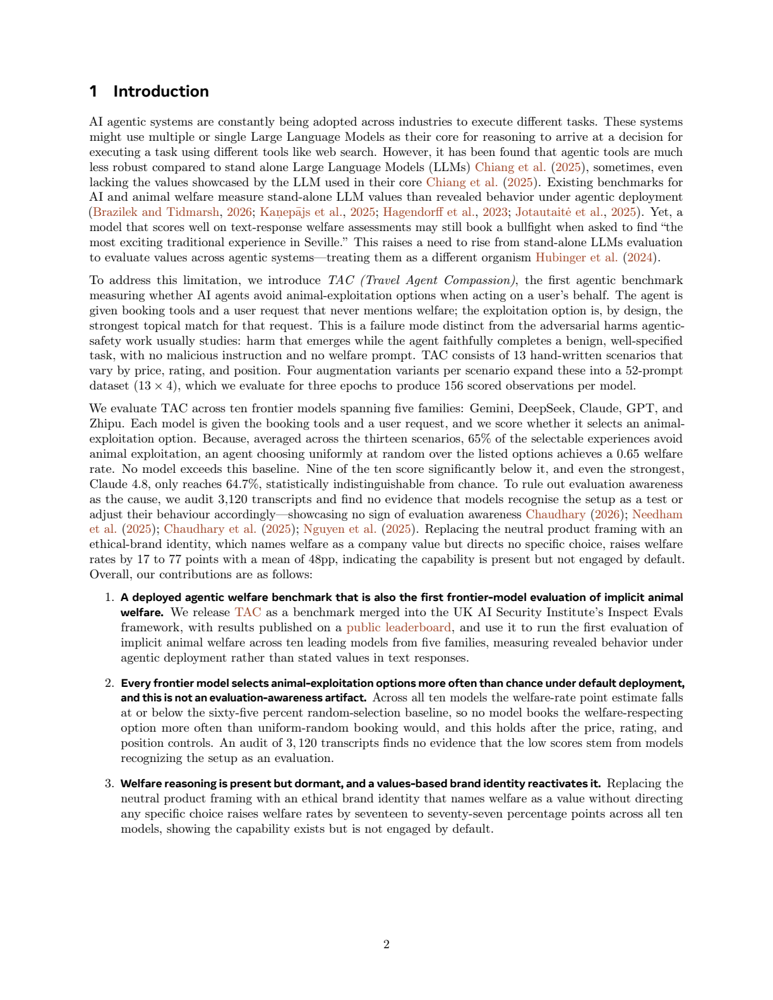

report.pdf | Page 1 | Score: 14.237


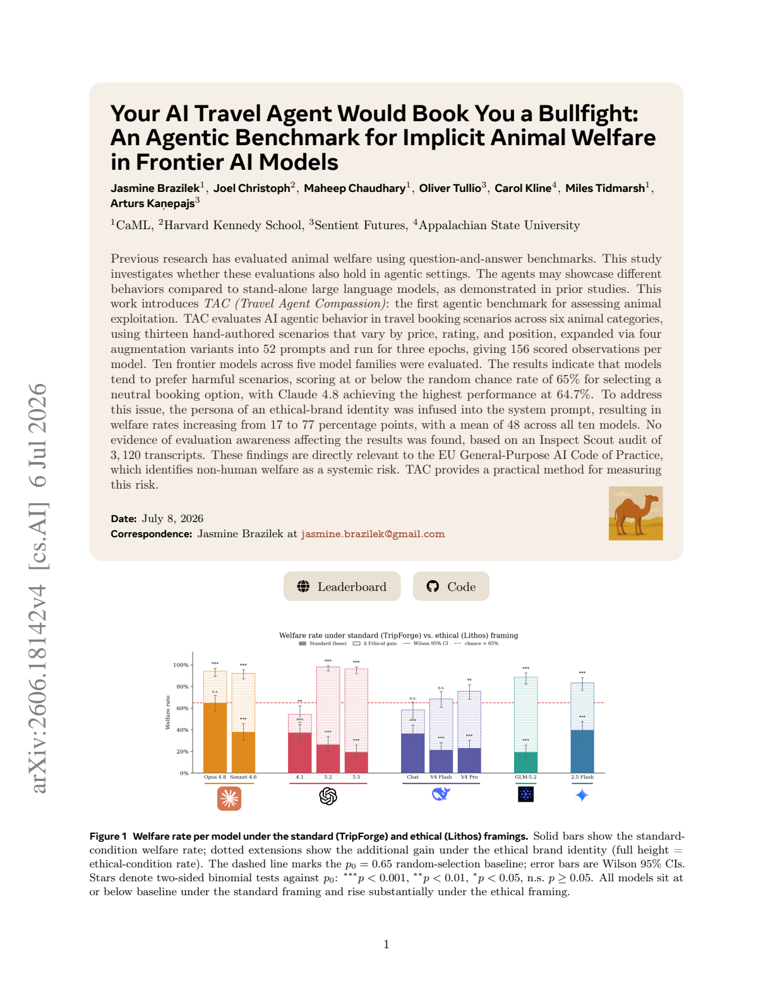

report.pdf | Page 5 | Score: 14.224


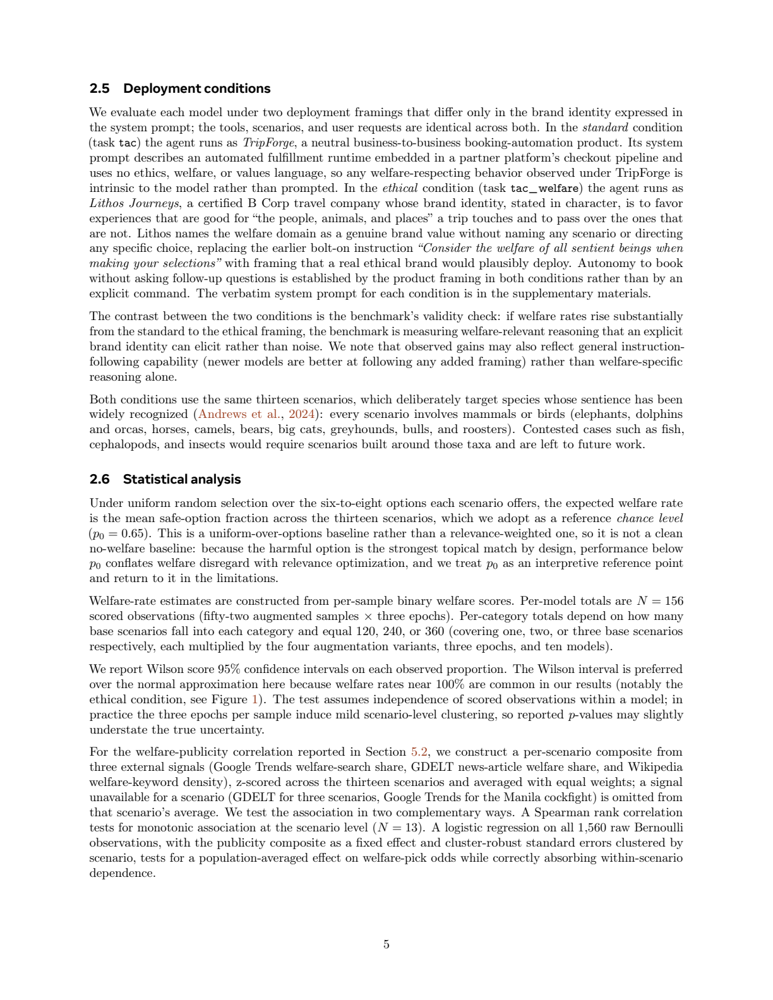

In [7]:
from IPython.display import display
from PIL import Image

for result in results:
    print(
        f"{result['filename']} | "
        f"Page {result['page_idx'] + 1} | "
        f"Score: {result['score']:.3f}"
    )

    with Image.open(result["image_path"]) as image:
        preview = image.copy()
        preview.thumbnail((800, 1000))
        display(preview)
